# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [4]:
titanic = pd.read_csv("/home/huawei/Descargas/machine learning/titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son categóricas?**



# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


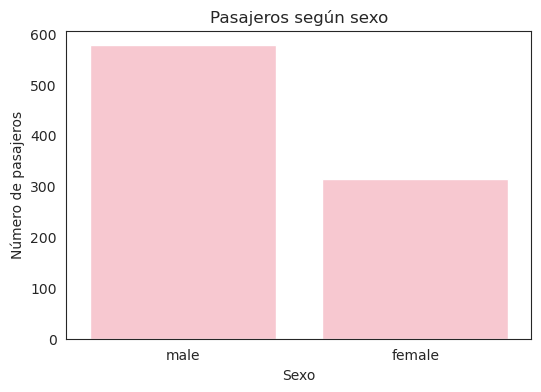

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="pink")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?


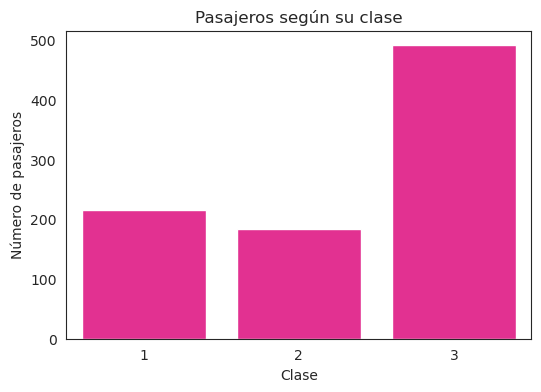

In [6]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="deeppink")

plt.xlabel("Clase")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según su clase")
plt.show()

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?


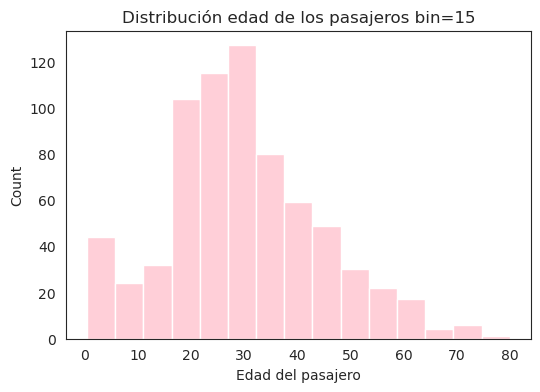

In [7]:
# Escriba aquí su código
# sns.histplot(...)
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Age", color="pink", bins = 15)
plt.xlabel('Edad del pasajero')
plt.title('Distribución edad de los pasajeros bin=15')
plt.show()

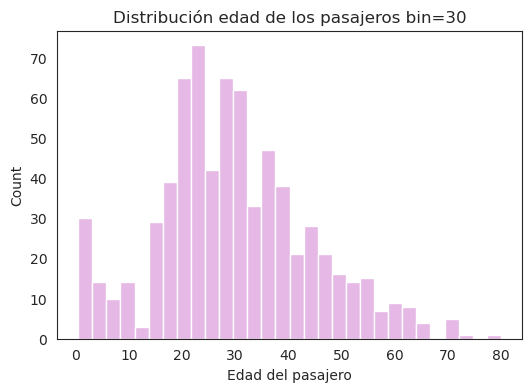

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Age", color="plum", bins = 30)
plt.xlabel('Edad del pasajero')
plt.title('Distribución edad de los pasajeros bin=30')
plt.show()

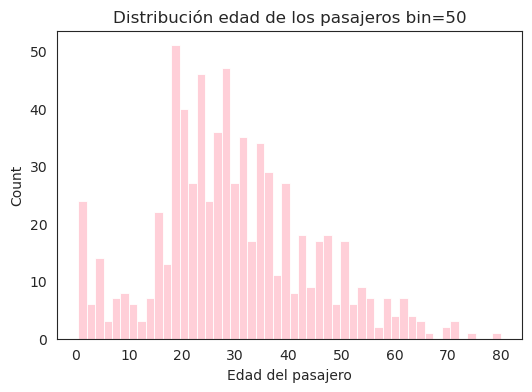

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Age", color="pink", bins = 50)
plt.xlabel('Edad del pasajero')
plt.title('Distribución edad de los pasajeros bin=50')
plt.show()

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?


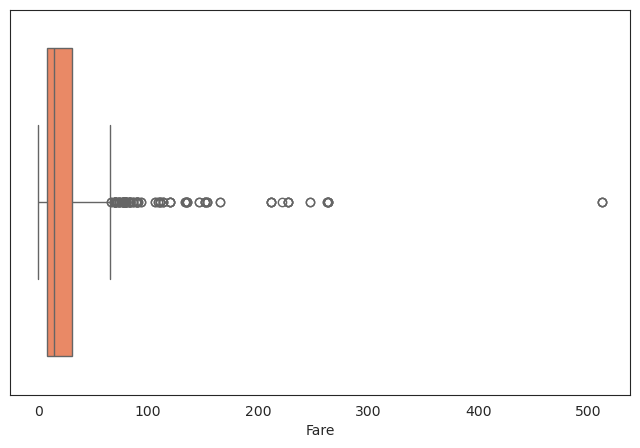

In [10]:
# Escriba aquí su código
plt.figure(figsize=(8,5))

sns.boxplot(x=titanic["Fare"], color="coral")#,whis = (0,100))
plt.show()

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [11]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


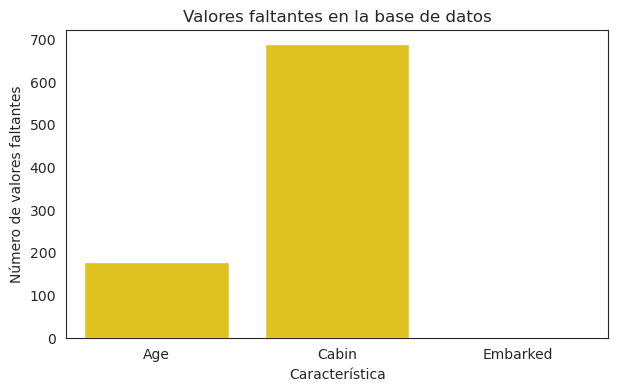

In [12]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?


29.69911764705882 nan


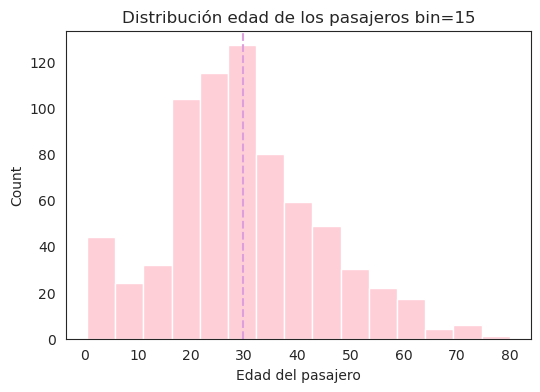

In [13]:
# Escriba aquí su código
media = np.mean(titanic['Age'])
mediana = np.median(titanic['Age'])
print(media, mediana)
#mediana nan
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Age", color="pink", bins = 15)
plt.axvline(media, linestyle='--', color='plum')
plt.axvline(mediana, linestyle='-',color = 'red' )
plt.xlabel('Edad del pasajero')
plt.title('Distribución edad de los pasajeros bin=15')

plt.show()

In [14]:
#No son similares, ya que el promedio 

**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?


In [15]:
#

**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No hay una única respuesta correcta: justifique su decisión.


**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?


# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


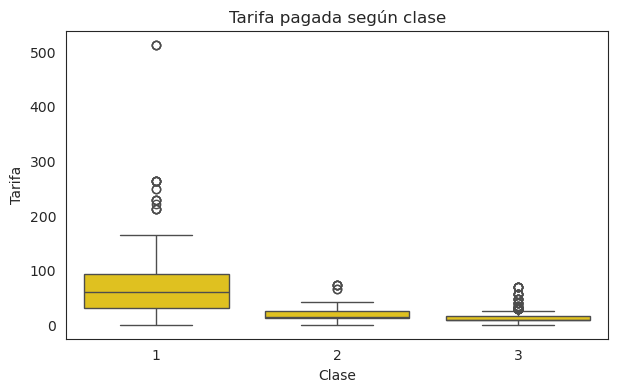

In [16]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?
- Hay dispersión dentro de cada clase?
- Existen valores extremos?
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?


### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?


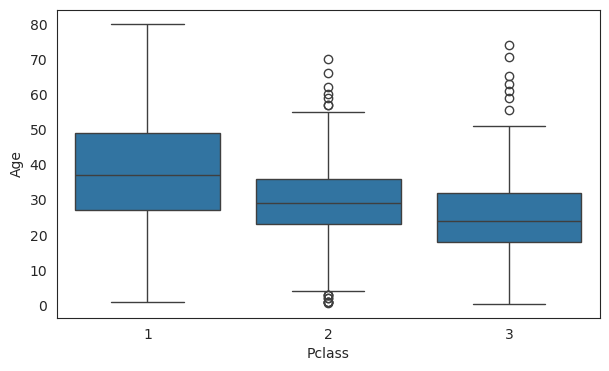

In [17]:
# Escriba aquí su código
# sns.boxplot(...)
plt.figure(figsize=(7,4))
sns.boxplot(data=titanic, x="Pclass", y="Age")
plt.show()

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [18]:
# Complete el código

titanic["Familia"] = titanic["SibSp"]+titanic["Parch"]+1
print(titanic['Familia'])

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Familia, Length: 891, dtype: int64


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?


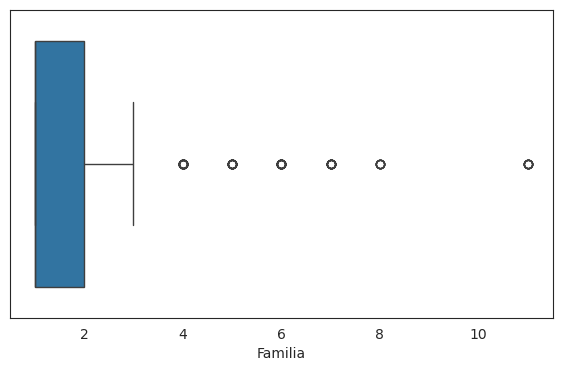

In [19]:
# Escriba aquí su código
plt.figure(figsize=(7,4))
sns.boxplot(data=titanic, x="Familia")#, y="Parch")
plt.show()

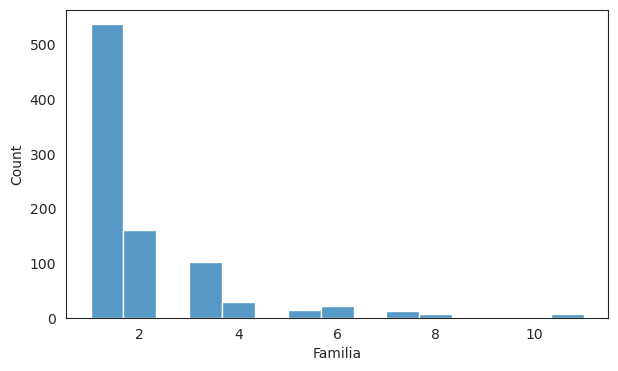

In [20]:
plt.figure(figsize=(7,4))
sns.histplot(data=titanic, x="Familia", bins=15)#, y="Parch")
plt.show()

In [21]:
#Mayoría viajaba solo, no hay grupos familiares tan grandes 

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


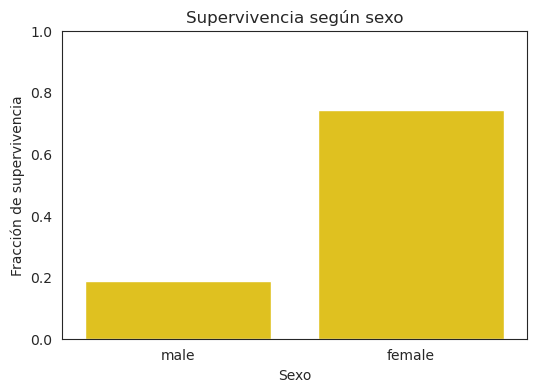

In [22]:
plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')
plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)
plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?
- Podemos concluir a partir de este gráfico por qué existe la diferencia?


In [ ]:
#No, es diferente, sobrevivieron más mujeres que hombres. 

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?


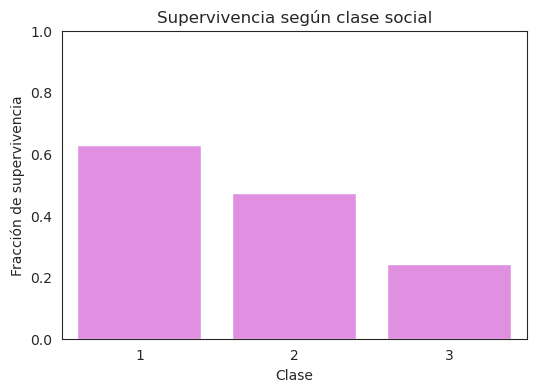

In [23]:
# Escriba aquí su código
plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='violet')
plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase social")
plt.ylim(0,1)
plt.show()
#Sii, la mayoria de sobrevivientes eran de la primera clase

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?


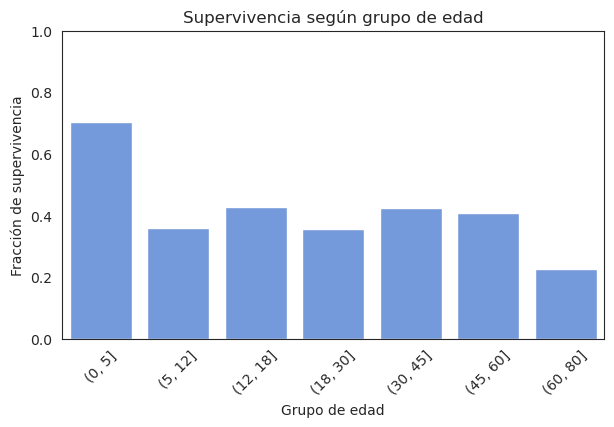

In [33]:
# Escriba aquí su código
plt.figure(figsize=(7,4))
#Bins por edad
bins_edad = [0, 5, 12, 18, 30, 45, 60, 80]
titanic["GrupoEdad"] = pd.cut(titanic["Age"], bins=bins_edad)
sns.barplot(data=titanic, x="GrupoEdad", y="Survived", errorbar=None, color='cornflowerblue')
plt.xlabel("Grupo de edad")
plt.ylabel("Supervivencia")
plt.title("Supervivencia según grupo de edad")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.show()
#Si, la supervivencia está asociada a la edad, ya que el grupo de 0-5 años fueron los que más sobrevivieron

**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?


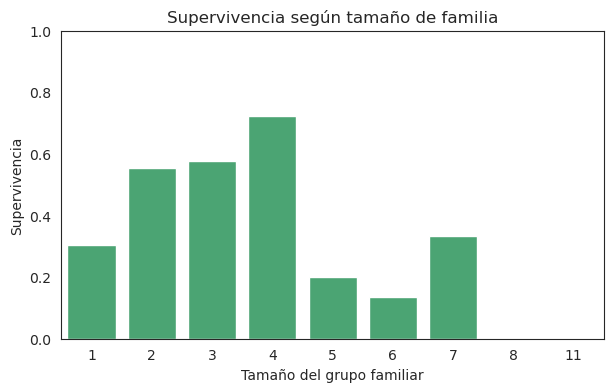

In [32]:
# Escriba aquí su código
plt.figure(figsize=(7,4))
sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color='mediumseagreen')
plt.xlabel("Tamaño del grupo familiar")
plt.ylabel("Supervivencia")
plt.title("Supervivencia según tamaño de familia")
plt.ylim(0,1)
plt.show()
#Viajar solo parace desfavorable, los grupos familiares 5 integrantes no sobrevivieron tanto

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


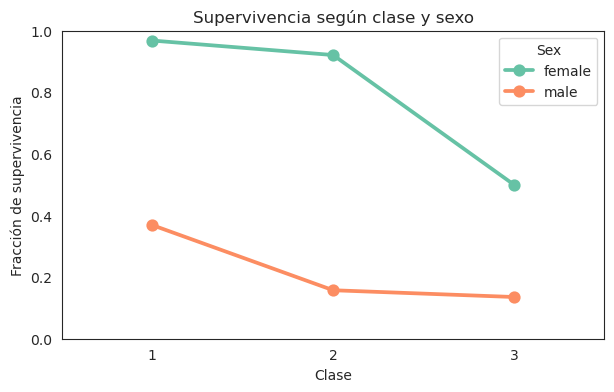

In [26]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?
- Qué información se perdía cuando mirábamos solamente `Pclass`?
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?



### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [34]:
# Complete el código
#niño menores de 16
def persona(fila):
    if fila["Age"] < 16:
        return "niño/a"
    elif fila["Sex"] == "female":
        return "mujer"
    else:
        return "hombre"
titanic["Persona"] = titanic.apply(persona, axis=1)


# Revise el resultado
titanic["Persona"].value_counts()


Persona
hombre    537
mujer     271
niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


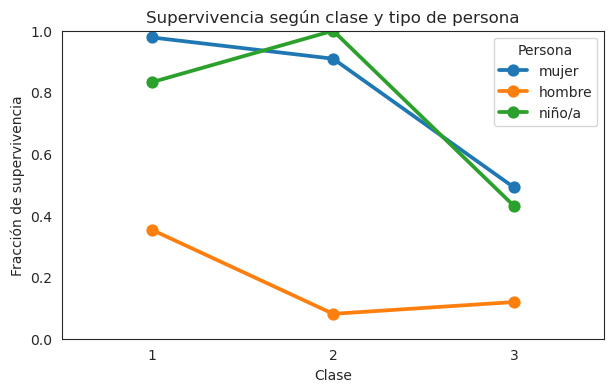

In [36]:
# Escriba aquí su código
plt.figure(figsize=(7,4))
sns.pointplot(data=titanic,x="Pclass",y="Survived",hue="Persona",errorbar=None)
plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y tipo de persona")
plt.ylim(0,1)
plt.show()
#Los niños no presentan el mismo patrón. Sii sigue siendo importante la clase, mayor supervivencia en niños de la clase 2 y mujeres 
#de primera clase

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


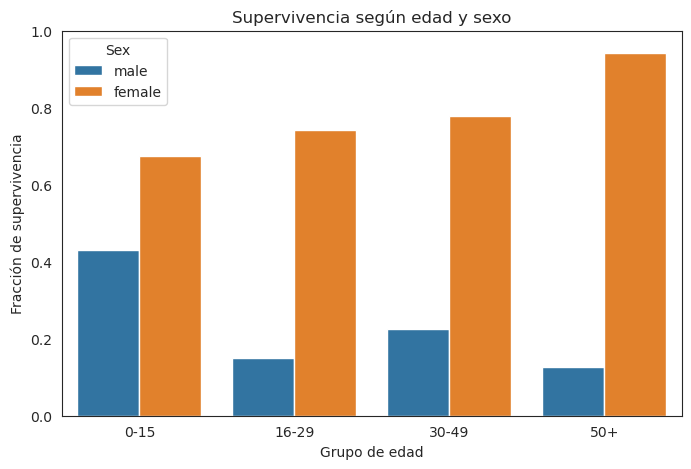

In [38]:
# Pregunta:
#cambia la supervivencia respecto a la edad y sexo de la persona?
# Código:
titanic["GrupoEdad"] = pd.cut(titanic["Age"], bins=[0, 16, 30, 50, 100], labels=["0-15", "16-29", "30-49", "50+"])
plt.figure(figsize=(8,5))
sns.barplot(data=titanic, x="GrupoEdad", y="Survived", hue="Sex", errorbar=None)
plt.xlabel("Grupo de edad")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según edad y sexo")
plt.ylim(0,1)
plt.show()

# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.


### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.


### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.


In [ ]:
#1. Los pasajeros del titanic eran hombres y mujeres de distintas edades y pertenecientes a las tres clases del barco.
#La mayoría de los pasajeros correspondía a adultos y existía una proporción importante de hombres. 
#La mayoría viajaba sola o en grupos familiares pequeños.

In [39]:
#2.La supervivencia estuvo asociada principalmente con el sexo y la clase, ya quelas mujeres
#sobrevivieorn mas que los hombres. También se observaron diferencias entre las tres clases,
#con una mayor supervivencia los de primera clase

In [ ]:
#3. considerar varias características simultáneamente, observamos que la relación entre clase y supervivencia
#no es exactamente igual para hombres y mujeres. Al separar los pasajeros por sexo aparecen 
#diferencias dentro de cada clase que no se observaban al analizar solamente Pclass

In [ ]:
#4. Sii, el sexo y la clase tiene información relacionada con la supervivencia, tambien
#la supervivencia asociada a la clase cambia cuando se considera también el sexo, por lo que
#analizar solamente una característica puede ocultar diferencias.

In [ ]:
#5. Un resultado que me pareció inesperado fue la gran diferencia de supervivencia entre hombres y mujeres.
#La observación es que las mujeres presentan una fracción de supervivencia considerablemente mayor que los hombres.
#Una posible hipótesis es que esto podría estar relacionado con el proceso de evacuación y el acceso a los botes salvavidas,
#aunque esta explicación no puede demostrarse solamente con los datos analizados.

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*


In [ ]:
#En esta muestra, el perfil de pasajero asociado con una mayor probabilidad de supervivencia corresponde principalmente
#a una mujer, especialmente si pertenecía a una clase alta. La edad y el tamaño del grupo familiar también pueden aportar 
#información adicional. Sin embargo, este perfil describe una asociación observada en los datos y no necesariamente representa 
#una relación causal.